In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

!pip install pennylane pennylane-lightning --upgrade -q

import pennylane as qml
import pennylane.math as qmath
import torch
import torch.nn as nn
from torch.utils.data import WeightedRandomSampler

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

Using device: cuda:0


In [24]:

BASE = "/content/drive/MyDrive/Quantum_ML/Team A/datasets/CICIoT2023/qadcp/quantum"

df_train   = pd.read_parquet("/kaggle/input/datasets/arjunenaik/dataset-qc/DATA_QC/q8_train.parquet")
df_test    = pd.read_parquet("/kaggle/input/datasets/arjunenaik/dataset-qc/DATA_QC/q8_test.parquet")
df_cal     = pd.read_parquet("/kaggle/input/datasets/arjunenaik/dataset-qc/DATA_QC/q8_calibration.parquet")
df_zeroday = pd.read_parquet("/kaggle/input/datasets/arjunenaik/dataset-qc/DATA_QC/q8_zeroday.parquet")

for name, df in [("train", df_train), ("test", df_test), ("cal", df_cal), ("zeroday", df_zeroday)]:
    print(f"{name}: {df.shape}")

df_train.head()

train: (132166, 11)
test: (18883, 11)
cal: (18883, 11)
zeroday: (10984, 11)


,urg_count,Duration,flow_duration,Variance,Std,HTTPS,Tot sum,Header_Length,label_multiclass,label_binary,label_family
0,0.022648,2.364978,0.003637,0.000000,0.017957,0.000000,1.057962,0.860762,DDoS-RSTFINFlood,1,ddos
1,1.162439,3.045862,0.378237,2.909113,1.699442,3.141593,1.142228,2.621899,BenignTraffic,0,benign
2,0.000000,2.364978,0.000000,0.000000,0.000000,0.000000,0.944141,0.000000,DDoS-ICMP_Flood,1,ddos
3,0.000000,2.363669,0.000071,0.472997,0.679082,0.000000,1.075915,0.791950,DDoS-TCP_Flood,1,ddos
4,0.000000,2.364978,0.000000,0.000000,0.000000,0.000000,1.057771,0.782123,DDoS-RSTFINFlood,1,ddos


In [25]:

for df in [df_train, df_test, df_cal, df_zeroday]:
    df.drop(columns=["label_family", "label_multiclass"], inplace=True, errors="ignore")

print("Raw train class balance:")
print(df_train.label_binary.value_counts())

# Class-balanced subsample (cap majority class at 5000 to fight imbalance)
df_cleaned_train = pd.concat([
    df_train[df_train.label_binary == 1].iloc[:500],
    df_train[df_train.label_binary == 0].iloc[:500],
], ignore_index=True)

df_cleaned_test    = df_test.iloc[:2000].reset_index(drop=True)
df_cleaned_cal      = df_cal.iloc[:2000].reset_index(drop=True)
df_cleaned_zeroday  = df_zeroday.iloc[:2000].reset_index(drop=True)

print("\nBalanced train class counts:")
print(df_cleaned_train.label_binary.value_counts())

feature_columns = [c for c in df_train.columns if c not in ("label_binary",)]
target_column = "label_binary"

X_train = df_cleaned_train[feature_columns]
y_train = df_cleaned_train[target_column].astype(int)

X_test = df_cleaned_test[feature_columns]
y_test = df_cleaned_test[target_column].astype(int)

X_cal = df_cleaned_cal[feature_columns]
y_cal = df_cleaned_cal[target_column].astype(int)

X_zeroday = df_cleaned_zeroday[feature_columns]

print(f"\nShape of X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape of X_test:  {X_test.shape}, y_test:  {y_test.shape}")
print(f"Shape of X_cal:   {X_cal.shape}, y_cal:   {y_cal.shape}")
print(f"Shape of X_zeroday: {X_zeroday.shape}")

Raw train class balance:
label_binary
1    128964
0      3202
Name: count, dtype: int64

Balanced train class counts:
label_binary
1    500
0    500
Name: count, dtype: int64

Shape of X_train: (1000, 8), y_train: (1000,)
Shape of X_test:  (2000, 8), y_test:  (2000,)
Shape of X_cal:   (2000, 8), y_cal:   (2000,)
Shape of X_zeroday: (2000, 8)


Original feature count: 8
PCA components retained (>=95% variance): 5
Cumulative explained variance: 96.58%
Per-component explained variance ratio: [0.6988 0.1247 0.0684 0.0422 0.0317]


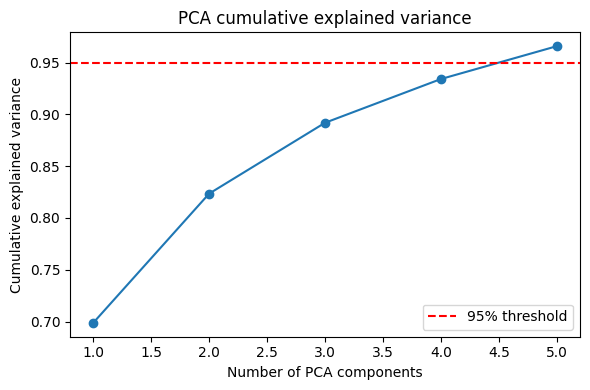


Data successfully scaled, PCA-reduced, and converted to angles.
A_train: (1000, 5), A_cal: (2000, 5), A_test: (2000, 5), A_zday: (2000, 5)
N_FEATURES (post-PCA) = 5, N_CLASSES = 2


In [26]:

# StandardScaler -> PCA (95% variance) -> angle encoding

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#  standardize 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_cal_scaled   = scaler.transform(X_cal)
X_zeroday_scaled = scaler.transform(X_zeroday)


pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)         
X_test_pca  = pca.transform(X_test_scaled)
X_cal_pca   = pca.transform(X_cal_scaled)
X_zeroday_pca = pca.transform(X_zeroday_scaled)

n_components = pca.n_components_
cum_var = np.cumsum(pca.explained_variance_ratio_)

print(f"Original feature count: {X_train_scaled.shape[1]}")
print(f"PCA components retained (>=95% variance): {n_components}")
print(f"Cumulative explained variance: {cum_var[-1]*100:.2f}%")
print(f"Per-component explained variance ratio: {np.round(pca.explained_variance_ratio_, 4)}")


plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.legend()
plt.tight_layout()
plt.show()

#  angle-encode 
def to_angles(X):
    """Clip to [-3, 3] std-devs, then map linearly to [0, pi] rotation angles."""
    Xc = np.clip(X, -3, 3)
    return (Xc + 3) / 6 * np.pi

A_train, A_cal, A_test, A_zday = map(
    to_angles, [X_train_pca, X_cal_pca, X_test_pca, X_zeroday_pca]
)

print("\nData successfully scaled, PCA-reduced, and converted to angles.")
print(f"A_train: {A_train.shape}, A_cal: {A_cal.shape}, A_test: {A_test.shape}, A_zday: {A_zday.shape}")

N_FEATURES = A_train.shape[1]   # now reflects PCA-reduced dimensionality
N_CLASSES  = int(np.unique(y_train).size)
print(f"N_FEATURES (post-PCA) = {N_FEATURES}, N_CLASSES = {N_CLASSES}")

In [27]:

# (DAY 8): Mixed-state VQC on default.mixed
#   + identity-block init (barren-plateau safe)
#   + gradient-variance monitor

N_QUBITS = 5
N_LAYERS = 3
NOISE_P  = 0.01

dev = qml.device("default.mixed", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def state_circuit_batched(x_batch, theta):
    """Data re-uploading VQC returning the exact mixed state (density matrix)."""
    n_feat = x_batch.shape[1]
    for layer in range(N_LAYERS):
        for w in range(N_QUBITS):
            qml.RY(x_batch[:, w % n_feat], wires=w)
            qml.RZ(x_batch[:, (w + 1) % n_feat], wires=w)
        for w in range(N_QUBITS):
            qml.RY(theta[layer, w, 0], wires=w)
            qml.RZ(theta[layer, w, 1], wires=w)
        for w in range(N_QUBITS):
            qml.CNOT(wires=[w, (w + 1) % N_QUBITS])
        for w in range(N_QUBITS):
            qml.DepolarizingChannel(NOISE_P, wires=w)
    return qml.density_matrix(wires=range(N_QUBITS))


def init_theta_identity_block(n_layers=N_LAYERS, n_qubits=N_QUBITS, eps=1e-2, dev_=device):
    """Small random init near identity — avoids barren-plateau random-circuit regime."""
    theta = eps * torch.randn(n_layers, n_qubits, 2, device=dev_)
    return nn.Parameter(theta)


def _build_pauliZ_ops(n_qubits, dev_):
    I = torch.eye(2, dtype=torch.cdouble, device=dev_)
    Z = torch.tensor([[1, 0], [0, -1]], dtype=torch.cdouble, device=dev_)
    ops = []
    for w in range(n_qubits):
        mats = [Z if i == w else I for i in range(n_qubits)]
        op = mats[0]
        for m in mats[1:]:
            op = torch.kron(op, m)
        ops.append(op)
    return ops

PAULI_Z_OPS = _build_pauliZ_ops(N_QUBITS, device)

def expvals_from_rho_batch(rho_batch):
    """Readout features: <Z_w> for each qubit w, for every rho in the batch."""
    return torch.stack([
        torch.stack([torch.real(torch.trace(rho @ op)) for op in PAULI_Z_OPS])
        for rho in rho_batch
    ])


def gradient_variance_probe(x_probe, n_trials=20, eps=1e-2):
    """Barren-plateau check: variance of a representative gradient component
    across fresh identity-block inits. Target: var > 1e-6."""
    grad_samples = []
    for _ in range(n_trials):
        theta = init_theta_identity_block(eps=eps)
        rho = state_circuit_batched(x_probe, theta)
        loss = torch.stack([torch.real(torch.trace(r @ r)) for r in rho]).mean()  # purity probe
        loss.backward()
        grad_samples.append(theta.grad[0, 0, 0].item())
    grad_samples = np.array(grad_samples)
    var = grad_samples.var()
    print(f"[grad-variance probe] mean={grad_samples.mean():.3e}  var={var:.3e}  "
          f"({'OK' if var > 1e-6 else 'BARREN PLATEAU RISK'})")
    return var


probe_x = torch.tensor(A_train[:8], dtype=torch.float32, device=device)
_ = gradient_variance_probe(probe_x, n_trials=20)

[grad-variance probe] mean=1.128e-04  var=2.462e-08  (BARREN PLATEAU RISK)


In [28]:

# (DAY 9): Running class prototypes + fidelity/trace-distance utils

def safe_fidelity(rho, sigma, eps=1e-7):
    f = qmath.fidelity(rho, sigma)
    return torch.clamp(f, 0.0, 1.0 - eps)

def safe_trace_distance(rho, sigma):
    return torch.clamp(qmath.trace_distance(rho, sigma), 0.0, 1.0)


class RunningPrototypes:
    """EMA prototype rho_c per known class, updated every training batch."""
    def __init__(self, momentum=0.9):
        self.momentum = momentum
        self.protos = {}

    def batch_class_means(self, rho_batch, y_batch):
        means = {}
        for c in torch.unique(y_batch):
            c_int = int(c)
            mask = (y_batch == c)
            rhos_c = [rho_batch[j] for j in range(len(rho_batch)) if mask[j]]
            means[c_int] = sum(rhos_c) / len(rhos_c)
        return means

    def update(self, batch_means):
        for c_int, batch_mean in batch_means.items():
            if c_int not in self.protos:
                self.protos[c_int] = batch_mean.detach().clone()
            else:
                self.protos[c_int] = (self.momentum * self.protos[c_int]
                                       + (1 - self.momentum) * batch_mean.detach())
        return self.protos

    def diagnostics(self):
        """H1 diagnostic: pairwise inter-class trace distance."""
        keys = list(self.protos.keys())
        report = {}
        for a in range(len(keys)):
            for b in range(a + 1, len(keys)):
                d = safe_trace_distance(self.protos[keys[a]], self.protos[keys[b]]).item()
                report[f"D(rho_{keys[a]}, rho_{keys[b]})"] = d
        return report


#  unit sanity check 
_rng = np.random.default_rng(0)
def _random_density_matrix(n_qubits=N_QUBITS, dev_=device):
    dim = 2 ** n_qubits
    A = torch.tensor(_rng.normal(size=(dim, dim)) + 1j * _rng.normal(size=(dim, dim)),
                      dtype=torch.cdouble, device=dev_)
    rho = A @ A.conj().T
    return rho / torch.trace(rho)

r1, r2 = _random_density_matrix(), _random_density_matrix()
print("Fidelity(r1,r1)  ≈ 1:", safe_fidelity(r1, r1).item())
print("Fidelity(r1,r2):     ", safe_fidelity(r1, r2).item())
print("TraceDist(r1,r1) ≈ 0:", safe_trace_distance(r1, r1).item())
print("TraceDist(r1,r2):    ", safe_trace_distance(r1, r2).item())

Fidelity(r1,r1)  ≈ 1: 0.9999999
Fidelity(r1,r2):      0.5796710079023886
TraceDist(r1,r1) ≈ 0: 0.0
TraceDist(r1,r2):     0.5630318728438279


In [ ]:

# (DAY 10): MAQT loss  L = L_CE + λ1·L_intra + λ2·L_inter
#   + unit tests on a toy 2-class problem

def focal_loss(logits, targets, gamma=2.0):
    ce = nn.functional.cross_entropy(logits, targets, reduction='none')
    pt = torch.exp(-ce)
    return ((1 - pt) ** gamma * ce).mean()


def maqt_loss(rho_batch, y_batch, logits, prototypes: RunningPrototypes, lam1, lam2, gamma=2.0):
    L_CE = focal_loss(logits, y_batch, gamma=gamma)

    batch_means = prototypes.batch_class_means(rho_batch, y_batch)
    ema_protos = prototypes.update(batch_means)

    intra_terms = []
    for c in torch.unique(y_batch):
        c_int = int(c)
        mask = (y_batch == c)
        for j in range(len(rho_batch)):
            if mask[j]:
                intra_terms.append(1 - safe_fidelity(rho_batch[j], ema_protos[c_int]))
    L_intra = torch.stack(intra_terms).mean()

    keys = list(ema_protos.keys())
    inter_terms = []
    for a in range(len(keys)):
        for b in range(a + 1, len(keys)):
            inter_terms.append(safe_trace_distance(ema_protos[keys[a]], ema_protos[keys[b]]))
    L_inter = (-torch.stack(inter_terms).mean() if inter_terms
               else torch.tensor(0.0, device=rho_batch.device))

    total = L_CE + lam1 * L_intra + lam2 * L_inter
    return total, {"L_CE": L_CE.item(), "L_intra": L_intra.item(),
                    "L_inter": L_inter.item(), "L_total": total.item()}


#  unit tests 
def _toy_2class_batch(n=16, n_feat=N_FEATURES, seed=0):
    g = torch.Generator(device='cpu').manual_seed(seed)
    x0 = torch.rand(n // 2, n_feat, generator=g) * 0.5 * np.pi
    x1 = torch.rand(n // 2, n_feat, generator=g) * 0.5 * np.pi + np.pi
    X = torch.cat([x0, x1], dim=0).to(device)
    y = torch.cat([torch.zeros(n // 2), torch.ones(n // 2)]).long().to(device)
    return X, y

def test_maqt_loss_terms():
    theta = init_theta_identity_block()
    head = nn.Linear(N_QUBITS, 2).to(device)
    protos = RunningPrototypes(momentum=0.9)

    Xb, yb = _toy_2class_batch()
    rho_batch = state_circuit_batched(Xb, theta)
    z_batch = expvals_from_rho_batch(rho_batch)
    logits = head(z_batch.to(torch.float32))

    loss, terms = maqt_loss(rho_batch, yb, logits, protos, lam1=0.5, lam2=0.1)
    assert torch.isfinite(loss)
    assert terms["L_intra"] >= 0
    loss.backward()
    assert theta.grad is not None and torch.isfinite(theta.grad).all()
    print("test_maqt_loss_terms PASSED:", terms)

def test_lambda_scaling_monotonic():
    theta = init_theta_identity_block()
    head = nn.Linear(N_QUBITS, 2).to(device)
    Xb, yb = _toy_2class_batch()
    rho_batch = state_circuit_batched(Xb, theta)
    z_batch = expvals_from_rho_batch(rho_batch)
    logits = head(z_batch.to(torch.float32))

    losses = []
    for lam in [0.0, 0.3, 0.6]:
        protos = RunningPrototypes(momentum=0.9)
        l, _ = maqt_loss(rho_batch, yb, logits, protos, lam1=lam, lam2=0.0)
        losses.append(l.item())
    assert losses[0] <= losses[1] <= losses[2] + 1e-6, f"non-monotonic in λ1: {losses}"
    print("test_lambda_scaling_monotonic PASSED:", losses)

test_maqt_loss_terms()
test_lambda_scaling_monotonic()

test_maqt_loss_terms PASSED: {'L_CE': 0.20785218477249146, 'L_intra': 0.5765801098424794, 'L_inter': -0.7949757466175617, 'L_total': 0.416644665031975}
test_lambda_scaling_monotonic PASSED: [0.19555531442165375, 0.3684773590765048, 0.5413994037313559]


epoch  1/10 | loss 0.0487 | L_CE 0.0487 | L_intra 0.4311 | L_inter -0.7379 | grad_var 5.21e-04 | intra_fid 0.569 | inter_TD 0.749
epoch  2/10 | loss 0.0942 | L_CE 0.0279 | L_intra 0.4188 | L_inter -0.7664 | grad_var 6.45e-04 | intra_fid 0.581 | inter_TD 0.746
epoch  3/10 | loss 0.1509 | L_CE 0.0273 | L_intra 0.3965 | L_inter -0.7469 | grad_var 5.82e-04 | intra_fid 0.604 | inter_TD 0.729
epoch  4/10 | loss 0.1512 | L_CE 0.0335 | L_intra 0.3807 | L_inter -0.7274 | grad_var 7.19e-04 | intra_fid 0.619 | inter_TD 0.721
epoch  5/10 | loss 0.1285 | L_CE 0.0287 | L_intra 0.3499 | L_inter -0.7511 | grad_var 5.79e-04 | intra_fid 0.650 | inter_TD 0.729
epoch  6/10 | loss 0.1319 | L_CE 0.0260 | L_intra 0.3619 | L_inter -0.7504 | grad_var 4.51e-04 | intra_fid 0.638 | inter_TD 0.727
epoch  7/10 | loss 0.1520 | L_CE 0.0356 | L_intra 0.3807 | L_inter -0.7394 | grad_var 7.81e-04 | intra_fid 0.619 | inter_TD 0.716
epoch  8/10 | loss 0.1284 | L_CE 0.0257 | L_intra 0.3576 | L_inter -0.7609 | grad_var 4.76

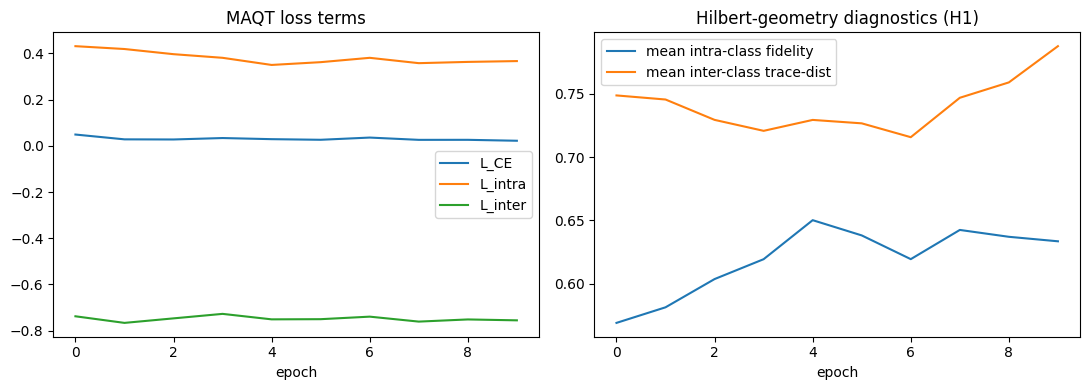

In [30]:

# (DAY 11): End-to-end MAQT training + H1 diagnostics

LR             = 0.05
EPOCHS         = 10
BATCH_SIZE     = 8
LAMBDA1_MAX    = 0.5
LAMBDA2_MAX    = 0.1
WARMUP_FRAC    = 0.2
GRAD_CLIP_NORM = 1.0
EMA_MOMENTUM   = 0.9
FOCAL_GAMMA    = 2.0

def curriculum_weight(epoch, total_epochs, base, warmup_frac=WARMUP_FRAC):
    warmup = max(int(warmup_frac * total_epochs), 1)
    return base * min(1.0, epoch / warmup)


def train_maqt(X_train_t, y_train_t, n_classes, epochs=EPOCHS,
               lam1_max=LAMBDA1_MAX, lam2_max=LAMBDA2_MAX, log_every=1, verbose=True):
    theta = init_theta_identity_block()
    head = nn.Linear(N_QUBITS, n_classes).to(device)
    opt = torch.optim.Adam(list([theta]) + list(head.parameters()), lr=LR)
    protos = RunningPrototypes(momentum=EMA_MOMENTUM)

    y_cpu = y_train_t.cpu().numpy().astype(int)
    class_counts = np.bincount(y_cpu, minlength=n_classes)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[y_cpu]

    history = {"loss": [], "L_CE": [], "L_intra": [], "L_inter": [],
               "grad_var": [], "intra_fid_gap": [], "inter_trace_dist": []}

    for epoch in range(epochs):
        lam1 = curriculum_weight(epoch, epochs, lam1_max)
        lam2 = curriculum_weight(epoch, epochs, lam2_max)
        sampler = list(WeightedRandomSampler(sample_weights, num_samples=len(y_train_t), replacement=True))
        perm = torch.tensor(sampler)

        epoch_terms = {"L_total": [], "L_CE": [], "L_intra": [], "L_inter": []}
        grad_vars, intra_fid_running = [], []

        for i in range(0, len(perm), BATCH_SIZE):
            idx = perm[i:i + BATCH_SIZE]
            xb, yb = X_train_t[idx].to(device), y_train_t[idx].to(device)

            rho_batch = state_circuit_batched(xb, theta)
            z_batch = expvals_from_rho_batch(rho_batch)
            logits = head(z_batch.to(torch.float32))

            loss, terms = maqt_loss(rho_batch, yb, logits, protos, lam1, lam2, gamma=FOCAL_GAMMA)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(list([theta]) + list(head.parameters()), GRAD_CLIP_NORM)
            grad_vars.append(theta.grad.var().item())
            opt.step()

            for k in epoch_terms:
                epoch_terms[k].append(terms[k])
            intra_fid_running.append(1 - terms["L_intra"])

        diag = protos.diagnostics()
        mean_inter_td = np.mean(list(diag.values())) if diag else 0.0
        mean_gv = np.mean(grad_vars)

        history["loss"].append(np.mean(epoch_terms["L_total"]))
        history["L_CE"].append(np.mean(epoch_terms["L_CE"]))
        history["L_intra"].append(np.mean(epoch_terms["L_intra"]))
        history["L_inter"].append(np.mean(epoch_terms["L_inter"]))
        history["grad_var"].append(mean_gv)
        history["intra_fid_gap"].append(np.mean(intra_fid_running))
        history["inter_trace_dist"].append(mean_inter_td)

        if verbose and (epoch + 1) % log_every == 0:
            print(f"epoch {epoch+1:2d}/{epochs} | loss {history['loss'][-1]:.4f} | "
                  f"L_CE {history['L_CE'][-1]:.4f} | L_intra {history['L_intra'][-1]:.4f} | "
                  f"L_inter {history['L_inter'][-1]:.4f} | grad_var {mean_gv:.2e} | "
                  f"intra_fid {history['intra_fid_gap'][-1]:.3f} | inter_TD {mean_inter_td:.3f}")
            if mean_gv < 1e-6:
                print("  ⚠ barren plateau detected")

    if verbose:
        print("\n[H1 diagnostic] pairwise inter-class trace distances:", protos.diagnostics())
    return theta, head, protos, history


# --- Day-11 first end-to-end run ---
X_train_t = torch.tensor(A_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train.values, dtype=torch.long, device=device)
X_test_t  = torch.tensor(A_test,  dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.long, device=device)
X_cal_t   = torch.tensor(A_cal,   dtype=torch.float32, device=device)
y_cal_t   = torch.tensor(y_cal.values,   dtype=torch.long, device=device)
X_zday_t  = torch.tensor(A_zday,  dtype=torch.float32, device=device)

theta, head, protos, history = train_maqt(X_train_t, y_train_t, n_classes=N_CLASSES)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["L_CE"], label="L_CE")
ax[0].plot(history["L_intra"], label="L_intra")
ax[0].plot(history["L_inter"], label="L_inter")
ax[0].set_title("MAQT loss terms"); ax[0].legend(); ax[0].set_xlabel("epoch")
ax[1].plot(history["intra_fid_gap"], label="mean intra-class fidelity")
ax[1].plot(history["inter_trace_dist"], label="mean inter-class trace-dist")
ax[1].set_title("Hilbert-geometry diagnostics (H1)"); ax[1].legend(); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

In [31]:

#(DAY 12): FGSM + PGD attacks, validated on plain VQC

def plain_vqc_logits(x_batch, theta_, head_):
    rho_batch = state_circuit_batched(x_batch, theta_)
    z_batch = expvals_from_rho_batch(rho_batch)
    return head_(z_batch.to(torch.float32))


def fgsm_attack(x_batch, y_batch, theta_, head_, epsilon, loss_fn=nn.CrossEntropyLoss()):
    x_batch = x_batch.clone().detach().requires_grad_(True)
    logits = plain_vqc_logits(x_batch, theta_, head_)
    loss = loss_fn(logits, y_batch)
    grad = torch.autograd.grad(loss, x_batch)[0]
    x_adv = x_batch + epsilon * grad.sign()
    return torch.clamp(x_adv, 0.0, np.pi).detach()


def pgd_attack(x_batch, y_batch, theta_, head_, epsilon, alpha, n_steps,
               loss_fn=nn.CrossEntropyLoss(), random_start=True):
    x_orig = x_batch.clone().detach()
    if random_start:
        x_adv = x_orig + torch.empty_like(x_orig).uniform_(-epsilon, epsilon)
        x_adv = torch.clamp(x_adv, 0.0, np.pi).detach()
    else:
        x_adv = x_orig.clone()

    for _ in range(n_steps):
        x_adv.requires_grad_(True)
        logits = plain_vqc_logits(x_adv, theta_, head_)
        loss = loss_fn(logits, y_batch)
        grad = torch.autograd.grad(loss, x_adv)[0]
        with torch.no_grad():
            x_adv = x_adv + alpha * grad.sign()
            x_adv = torch.max(torch.min(x_adv, x_orig + epsilon), x_orig - epsilon)
            x_adv = torch.clamp(x_adv, 0.0, np.pi)
    return x_adv.detach()


def evaluate_attack(X, y, theta_, head_, attack_fn, **kwargs):
    with torch.no_grad():
        clean_acc = (plain_vqc_logits(X, theta_, head_).argmax(1) == y).float().mean().item()
    X_adv = attack_fn(X, y, theta_, head_, **kwargs)
    with torch.no_grad():
        adv_acc = (plain_vqc_logits(X_adv, theta_, head_).argmax(1) == y).float().mean().item()
    return clean_acc, adv_acc, X_adv


def train_plain_vqc(X_train_t, y_train_t, n_classes, epochs=8, lr=0.05, batch_size=16):
    theta_p = init_theta_identity_block()
    head_p = nn.Linear(N_QUBITS, n_classes).to(device)
    opt = torch.optim.Adam(list([theta_p]) + list(head_p.parameters()), lr=lr)
    ce = nn.CrossEntropyLoss()
    n = len(X_train_t)
    for epoch in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = X_train_t[idx], y_train_t[idx]
            logits = plain_vqc_logits(xb, theta_p, head_p)
            loss = ce(logits, yb)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(list([theta_p]) + list(head_p.parameters()), 1.0)
            opt.step()
        print(f"[plain VQC] epoch {epoch+1}/{epochs} loss {loss.item():.4f}")
    return theta_p, head_p


theta_plain, head_plain = train_plain_vqc(X_train_t, y_train_t, n_classes=N_CLASSES)

clean_acc, fgsm_acc, _ = evaluate_attack(X_test_t, y_test_t, theta_plain, head_plain,
                                          fgsm_attack, epsilon=0.15)
print(f"\n[FGSM] clean_acc={clean_acc:.3f} adv_acc={fgsm_acc:.3f} degradation={clean_acc-fgsm_acc:.3f}")

clean_acc2, pgd_acc, _ = evaluate_attack(X_test_t, y_test_t, theta_plain, head_plain,
                                          pgd_attack, epsilon=0.15, alpha=0.03, n_steps=10)
print(f"[PGD]  clean_acc={clean_acc2:.3f} adv_acc={pgd_acc:.3f} degradation={clean_acc2-pgd_acc:.3f}")

print("\nAttack framework validated against the pre-MAQT baseline." if fgsm_acc < clean_acc
      else "\n⚠ FGSM did not degrade accuracy — inspect attack wiring before trusting Prop-2 validation.")

[plain VQC] epoch 1/8 loss 0.0208
[plain VQC] epoch 2/8 loss 0.5453
[plain VQC] epoch 3/8 loss 0.0405
[plain VQC] epoch 4/8 loss 0.1483
[plain VQC] epoch 5/8 loss 0.1363
[plain VQC] epoch 6/8 loss 0.0119
[plain VQC] epoch 7/8 loss 0.0384
[plain VQC] epoch 8/8 loss 0.0045

[FGSM] clean_acc=0.965 adv_acc=0.899 degradation=0.067
[PGD]  clean_acc=0.965 adv_acc=0.897 degradation=0.068

Attack framework validated against the pre-MAQT baseline.


λ1=0.10 λ2=0.10 -> inter_TD=0.799 intra_fid=0.615 min_gv=3.53e-04 stable=True
λ1=0.10 λ2=0.05 -> inter_TD=0.783 intra_fid=0.599 min_gv=2.86e-04 stable=True
λ1=0.05 λ2=0.10 -> inter_TD=0.786 intra_fid=0.618 min_gv=2.86e-04 stable=True
λ1=0.05 λ2=0.05 -> inter_TD=0.715 intra_fid=0.582 min_gv=2.90e-04 stable=True

=== λ1/λ2 SENSITIVITY REPORT ===
 lambda1  lambda2  mean_inter_TD  mean_intra_fid  min_grad_var  stable    score
    0.10     0.10       0.798829        0.614940      0.000353    True 1.413769
    0.05     0.10       0.785524        0.617919      0.000286    True 1.403444
    0.10     0.05       0.783265        0.598532      0.000286    True 1.381797
    0.05     0.05       0.714788        0.581511      0.000290    True 1.296299

Recommended operating point: λ1=0.1, λ2=0.1 (inter_TD=0.799, intra_fid=0.615, stable=True)


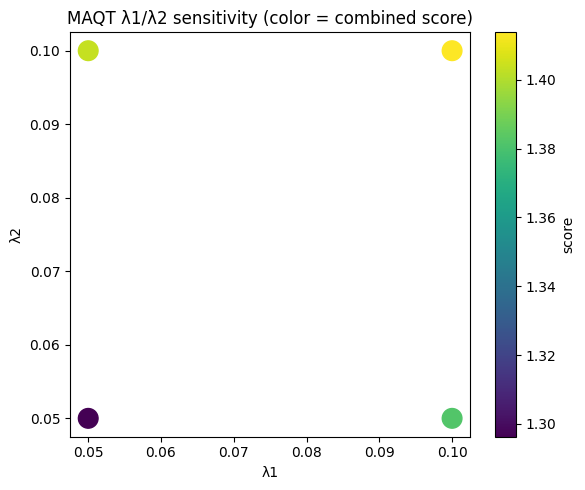

In [ ]:

#  (DAY 13): λ1/λ2 sweep for tight, separated prototypes

def run_lambda_sweep(X_train_t, y_train_t, n_classes,
                      lambda1_grid=(0.1, 0.05),
                      lambda2_grid=(0.1, 0.05),
                      epochs=6):
    records = []
    for lam1_max in lambda1_grid:
        for lam2_max in lambda2_grid:
            _, _, protos_sweep, hist = train_maqt(
                X_train_t, y_train_t, n_classes,
                epochs=epochs, lam1_max=lam1_max, lam2_max=lam2_max, verbose=False
            )
            diag = protos_sweep.diagnostics()
            mean_inter_td = np.mean(list(diag.values())) if diag else 0.0
            final_intra_fid = hist["intra_fid_gap"][-1]
            min_grad_var = min(hist["grad_var"])

            records.append({
                "lambda1": lam1_max, "lambda2": lam2_max,
                "mean_inter_TD": mean_inter_td, "mean_intra_fid": final_intra_fid,
                "min_grad_var": min_grad_var, "stable": min_grad_var > 1e-6
            })
            print(f"λ1={lam1_max:.2f} λ2={lam2_max:.2f} -> inter_TD={mean_inter_td:.3f} "
                  f"intra_fid={final_intra_fid:.3f} min_gv={min_grad_var:.2e} "
                  f"stable={min_grad_var > 1e-6}")
    return records


sweep_records = run_lambda_sweep(X_train_t, y_train_t, n_classes=N_CLASSES, epochs=6)

df_sweep = pd.DataFrame(sweep_records)
df_sweep["score"] = df_sweep["mean_inter_TD"] + df_sweep["mean_intra_fid"] - (~df_sweep["stable"]).astype(int)
best_row = df_sweep.sort_values("score", ascending=False).iloc[0]

print("\n=== λ1/λ2 SENSITIVITY REPORT ===")
print(df_sweep.sort_values("score", ascending=False).to_string(index=False))
print(f"\nRecommended operating point: λ1={best_row['lambda1']}, λ2={best_row['lambda2']} "
      f"(inter_TD={best_row['mean_inter_TD']:.3f}, intra_fid={best_row['mean_intra_fid']:.3f}, "
      f"stable={bool(best_row['stable'])})")

LAMBDA1_MAX = float(best_row["lambda1"])
LAMBDA2_MAX = float(best_row["lambda2"])

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(df_sweep["lambda1"], df_sweep["lambda2"], c=df_sweep["score"], s=200, cmap="viridis")
ax.set_xlabel("λ1"); ax.set_ylabel("λ2")
ax.set_title("MAQT λ1/λ2 sensitivity (color = combined score)")
plt.colorbar(sc, label="score")
plt.tight_layout(); plt.show()

In [ ]:

# (DAY 14): Final MAQT retrain with tuned λ1/λ2,
# emit real prototypes {rho_c}

import os
import pickle
import torch  

print(f"Using tuned hyperparameters: λ1_max={LAMBDA1_MAX}, λ2_max={LAMBDA2_MAX}")

# Execute training
theta_final, head_final, protos_final, history_final = train_maqt(
    X_train_t,
    y_train_t,
    n_classes=N_CLASSES,
    epochs=15,
    lam1_max=LAMBDA1_MAX,
    lam2_max=LAMBDA2_MAX,
)

# Run diagnostics
final_diag = protos_final.diagnostics()
print("\n=== Final Hilbert-geometry diagnostics (dataset 1) ===")
for k, v in final_diag.items():
    print(f"  {k}: {v:.4f}")

sep_ok = all(v > 0.15 for v in final_diag.values()) if final_diag else False
print(f"Proposition 2 separability precondition satisfied: {sep_ok}")

# Pack the checkpoint dictionary
checkpoint = {
    "theta": theta_final.detach().cpu(),
    "head_state_dict": head_final.state_dict(),
    "N_QUBITS": N_QUBITS,
    "N_LAYERS": N_LAYERS,
    "NOISE_P": NOISE_P,
    "lambda1_max": LAMBDA1_MAX,
    "lambda2_max": LAMBDA2_MAX,
    "history": history_final,
    "scaler_mean": scaler.mean_,
    "scaler_scale": scaler.scale_,
    "pca_components": pca.components_,
    "pca_mean": pca.mean_,
    "pca_n_components": pca.n_components_,
}


ckpt_dir = "/kaggle/working/Quantum_ML/Team_B/checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

ckpt_path = os.path.join(ckpt_dir, "maqt_day14.pt")
torch.save(checkpoint, ckpt_path)
print(f"\nSaved MAQT checkpoint -> {ckpt_path}")


proto_export = {
    c: rho.detach().cpu().numpy() for c, rho in protos_final.protos.items()
}
proto_path = "/kaggle/working/prototypes_dataset1.pkl"

with open(proto_path, "wb") as f:
    pickle.dump(proto_export, f)

print(f"Published prototype density matrices -> {proto_path}")
print(
    f"Classes exported: {list(proto_export.keys())}, each ρ_c shape: {list(proto_export.values())[0].shape}"
)


print("\n=== WEEK 2 SUMMARY ===")
print(f"Final train loss: {history_final['loss'][-1]:.4f}")
print(f"Final intra-class fid: {history_final['intra_fid_gap'][-1]:.4f}")
print(f"Final inter-class TD: {history_final['inter_trace_dist'][-1]:.4f}")
print(f"Min grad variance seen: {min(history_final['grad_var']):.2e}")
print("Ready for Week-3 conformal calibration on 'prototypes_dataset1.pkl'.")


Using tuned hyperparameters: λ1_max=0.1, λ2_max=0.1
epoch  1/15 | loss 0.0438 | L_CE 0.0438 | L_intra 0.4327 | L_inter -0.7467 | grad_var 4.05e-04 | intra_fid 0.567 | inter_TD 0.764
epoch  2/15 | loss 0.0191 | L_CE 0.0306 | L_intra 0.4116 | L_inter -0.7569 | grad_var 4.65e-04 | intra_fid 0.588 | inter_TD 0.755
epoch  3/15 | loss 0.0069 | L_CE 0.0317 | L_intra 0.3879 | L_inter -0.7609 | grad_var 3.70e-04 | intra_fid 0.612 | inter_TD 0.735
epoch  4/15 | loss -0.0215 | L_CE 0.0202 | L_intra 0.3606 | L_inter -0.7775 | grad_var 2.51e-04 | intra_fid 0.639 | inter_TD 0.756
epoch  5/15 | loss -0.0112 | L_CE 0.0283 | L_intra 0.3717 | L_inter -0.7666 | grad_var 3.93e-04 | intra_fid 0.628 | inter_TD 0.758
epoch  6/15 | loss -0.0120 | L_CE 0.0312 | L_intra 0.3477 | L_inter -0.7793 | grad_var 3.70e-04 | intra_fid 0.652 | inter_TD 0.707
epoch  7/15 | loss -0.0155 | L_CE 0.0263 | L_intra 0.3581 | L_inter -0.7755 | grad_var 3.07e-04 | intra_fid 0.642 | inter_TD 0.790
epoch  8/15 | loss -0.0238 | L_CE 

In [34]:
!zip -r quantum_ml_results.zip /kaggle/working/Quantum_ML

  adding: kaggle/working/Quantum_ML/ (stored 0%)
  adding: kaggle/working/Quantum_ML/.ipynb_checkpoints/ (stored 0%)
  adding: kaggle/working/Quantum_ML/Team_A/ (stored 0%)
  adding: kaggle/working/Quantum_ML/Team_A/checkpoints/ (stored 0%)
  adding: kaggle/working/Quantum_ML/Team_A/checkpoints/maqt_day14.pt (deflated 48%)


In [ ]:
from IPython.display import FileLink
FileLink(r'quantum_ml_results.zip')